# Phantom Analysis: Off-Center Rounded-Rectangle Gap, Standard Pipeline, Multiple Downstream Computations

A *phantom* is a feature in a downstream computation that looks like signal but is created entirely by the measurement gap. The framework's central claim is that the geometry of the gap fully determines the geometry of the phantom in every linear computation. The shape of the gap shows up in:

- the **spectrum** (as a Fourier-transform envelope around each true peak),
- **cross-correlation variance** (as a bump in 2D lag space whose footprint is twice the gap dimensions),
- **power-spectrum estimation** (as a smearing kernel $|\hat M|^2$ applied to the true PSD),
- the **two-point correlation function** (as a multiplicative bias factor $A_M(r)/V$ — exactly the Landy-Szalay correction),
- **Wiener inpainting** (as a recoverability lower bound through the framework's principal-angle suppression).

All six of these phantom signatures are computable in advance from the mask $M(x,y)$ alone, or from $M$ and the noise PSD $S_n(k)$ — no observed data required. This notebook fixes one gap geometry — a small rounded rectangle, off-center on a 2D periodic domain — and runs it through six common downstream computations that practitioners actually do, demonstrating each phantom and its framework prediction with Monte Carlo verification.

**Pipeline used throughout.** Observe $y^{(i)} = M\cdot(s + n^{(i)})$, then whiten $\tilde y^{(i)} = W\cdot y^{(i)}$ with $W = 1/\sqrt{S_n}$. This is the standard signal-processing pipeline used in matched filtering, gravitational-wave detection, radar processing, cosmology likelihoods, geomagnetic field analysis, and many other domains.

## §1. Setup

We work on a 2D periodic domain $[-\pi, \pi]^2$ with $N = 128$ samples per side, so the spatial step is $dx = 2\pi/N \approx 0.049$. The mask $M(x,y)$ is the indicator function of the unmasked region: $M = 1$ where we have measurements, $M = 0$ inside the gap. Throughout the notebook, applying the mask to a field means pointwise multiplication: $(Mf)(x) = M(x)\,f(x)$, which zeros out the masked region while leaving the rest unchanged.

### The gap geometry

The gap is a *small rounded rectangle*: a rectangle of half-widths $W \times H$ whose four 90° corners have been replaced with quarter-circle arcs of radius $r$. Equivalently — and how the code constructs it — the gap is the Minkowski sum of an inner "core" rectangle of half-widths $(W-r)\times(H-r)$ with a disk of radius $r$. A point $(x,y)$ is inside the gap if and only if its distance to the inner core rectangle is less than $r$.

We place the gap *well off-center* in the upper-right quadrant, at position $(x_0, y_0) = (1.5,\,1.3)$. The placement matters for §7 (Wiener inpainting) — where the *interior* of the mask is, geometrically, where information is fundamentally lost — but is invisible to the spectral, cross-correlation, PSD, and two-point analyses, because those quantities depend only on $|\hat M|$ or $A_M$, both of which are translation-invariant.

### The colored noise model

The noise has power spectral density (PSD)
$$S_n(k) \;=\; \frac{\sigma_0^2 \, k_c^2}{k_c^2 + |k|^2}$$
with corner wavenumber $k_c = 3$ and overall amplitude $\sigma_0 = 1$. This is a 2D Lorentzian: peaked at $k = 0$, decaying as $1/|k|^2$ at high spatial frequencies. Such noise is *low-spatial-frequency dominated* — it has a real-space correlation length $\sim 1/k_c \approx 0.33$, meaning two pixels less than $0.33$ apart have correlated noise, while pixels farther than ~1 apart are essentially uncorrelated. This is realistic for many measurement scenarios (1/$f$ instrumental drift in time series, atmospheric turbulence in optical imaging, foreground residuals in CMB, etc.).

The PSD is a covariance description in the Fourier basis: for stationary Gaussian noise, $\mathbb{E}[\hat n(k_1)\,\hat n^*(k_2)] = N^2 \cdot S_n(k_1)\,\delta_{k_1,k_2}$ in our discrete-FFT normalization. Equivalently in real space, the noise autocorrelation $\langle n(x)n(x+r)\rangle = \mathcal{F}^{-1}[S_n](r)$.

### The whitening filter

The standard signal-processing whitening filter is $W(k) = 1/\sqrt{S_n(k)}$. By construction, applying $W$ to the noise yields a field with flat (white) PSD: $W\cdot n$ has $\mathbb{E}[|\widehat{Wn}|^2(k)] = N^2$ uniform in $k$. This is the optimal preprocessing step for matched-filter detection in colored noise: after whitening, the matched filter against a whitened template gives the Neyman-Pearson optimal test statistic.

For our Lorentzian noise, $W(k) = \sqrt{(k_c^2 + |k|^2)/(\sigma_0^2 k_c^2)}$ — small at $k=0$, growing roughly linearly at high $|k|$. The whitening filter *boosts high spatial frequencies* — it has to, in order to flatten a noise spectrum that falls at high $|k|$.

### The figure below

Three panels: (1) the mask itself, with a red dot at the gap center and a dashed red outline showing the gap boundary; (2) $\log_{10}S_n(k)$ on the Fourier grid, showing the PSD decreasing radially from the origin; (3) $\log_{10}W(k) = -\tfrac{1}{2}\log_{10}S_n$, the inverse — small near origin (suppress where noise is loud), large at edges (boost where noise is quiet).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def bold_text(ax, x, y, txt, **kw):
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    t = ax.text(x, y, txt, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t


def outline_rounded_rect(ax, W, H, r, x0=0, y0=0, color='red', ls='--', lw=1.5):
    bbox = FancyBboxPatch((x0 - W + r, y0 - H + r), 2 * (W - r), 2 * (H - r),
                          boxstyle=f'round,pad=0,rounding_size={r}',
                          fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
    ax.add_patch(bbox)

In [2]:
# ---- 2D domain ----
N = 128
L = 2 * np.pi
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

# ---- Off-center, small rounded-rectangle gap ----
W_rect, H_rect, r_corner = 1.0, 0.6, 0.20
x_center, y_center = 1.5, 1.3

dx_in = np.maximum(np.abs(X - x_center) - (W_rect - r_corner), 0)
dy_in = np.maximum(np.abs(Y - y_center) - (H_rect - r_corner), 0)
dist_to_inner = np.sqrt(dx_in**2 + dy_in**2)
in_gap = dist_to_inner < r_corner
M = (~in_gap).astype(float)

# ---- Wavenumber grid ----
kx_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx_arr, ky_arr, indexing='ij')
K_mag = np.sqrt(KX**2 + KY**2)

# ---- Colored noise PSD and whitening filter ----
k_c = 3.0
sigma_0 = 1.0
S_n = sigma_0**2 * k_c**2 / (k_c**2 + K_mag**2)
W_kernel = 1.0 / np.sqrt(S_n)

V = L * L  # domain volume

print(f'Domain: {N}x{N} on [-pi,pi]^2, dx = {dx:.4f}, V = {V:.4f}')
print(f'Mask: rounded rectangle at ({x_center}, {y_center})')
print(f'  W = {W_rect}, H = {H_rect}, corner radius = {r_corner}')
print(f'  Mask area = {(1-M).sum()*dx**2:.4f} '
      f'({100*(1-M).mean():.2f}% of domain)')
print(f'Noise: 2D Lorentzian PSD, k_c = {k_c}, '
      f'real-space correlation length ~ 1/k_c = {1/k_c:.3f}')
print(f'Whitening: W(0) = {W_kernel[0,0]:.4f}, '
      f'W(k_max) = {W_kernel[N//2, N//2]:.4f}')

Domain: 128x128 on [-pi,pi]^2, dx = 0.0491, V = 39.4784
Mask: rounded rectangle at (1.5, 1.3)
  W = 1.0, H = 0.6, corner radius = 0.2
  Mask area = 2.3036 (5.83% of domain)
Noise: 2D Lorentzian PSD, k_c = 3.0, real-space correlation length ~ 1/k_c = 0.333
Whitening: W(0) = 1.0000, W(k_max) = 30.1865


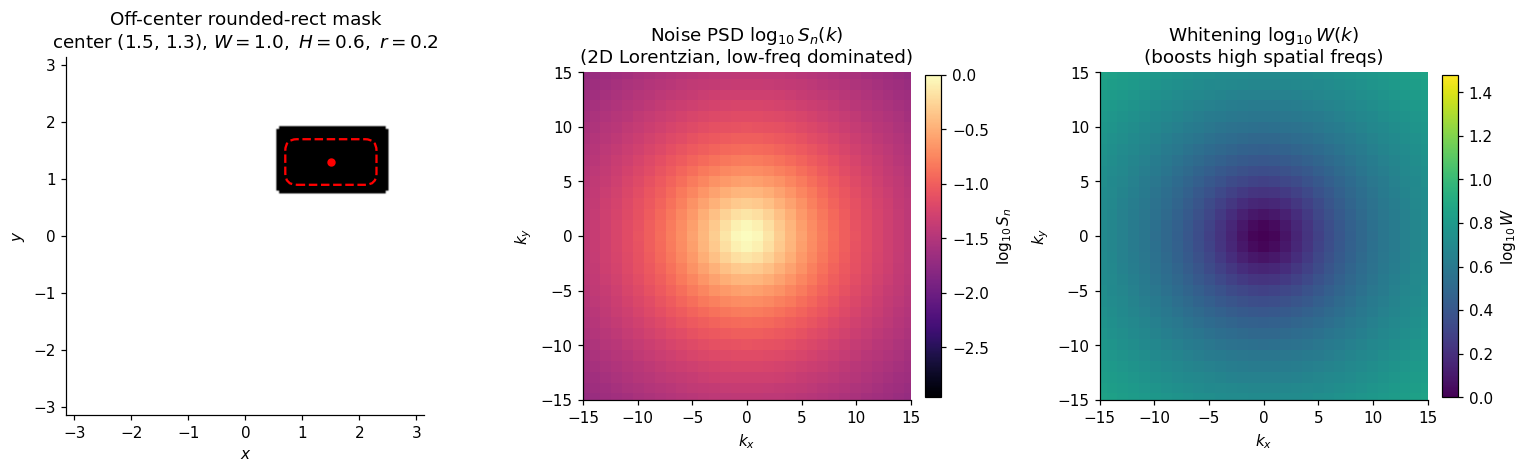

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Mask
ax = axes[0]
ax.imshow(M.T, cmap='gray', origin='lower',
          extent=[-L/2, L/2, -L/2, L/2], vmin=0, vmax=1)
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center)
ax.scatter([x_center], [y_center], s=20, c='red', zorder=5)
ax.set_title(f'Off-center rounded-rect mask\ncenter ({x_center}, {y_center}), '
             f'$W={W_rect},\\ H={H_rect},\\ r={r_corner}$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

# PSD
ax = axes[1]
S_n_c = np.fft.fftshift(S_n)
kx_c = np.fft.fftshift(kx_arr)
im = ax.imshow(np.log10(S_n_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Noise PSD $\log_{10} S_n(k)$' + '\n(2D Lorentzian, low-freq dominated)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} S_n$')

# Whitening
ax = axes[2]
W_c = np.fft.fftshift(W_kernel)
im = ax.imshow(np.log10(W_c.T), cmap='viridis', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Whitening $\log_{10} W(k)$' + '\n(boosts high spatial freqs)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} W$')

plt.tight_layout()
plt.show()

## §2. Spectral matched filter (single stream)

### What we're computing

The matched filter is the optimal linear detector for a known signal in additive Gaussian noise: project the data onto a noise-whitened version of the template, then threshold. For a coherent plane-wave signal of unknown amplitude at frequency $k_0$, the natural template family is $\{\cos(k\cdot x)\}_k$ — sinusoids at every candidate frequency $k$. The matched filter scan over $k$ is then exactly the Fourier transform of the data. So *spectral analysis is matched filtering*: looking at $|\hat y(k)|^2$ as a function of $k$ is the Neyman-Pearson optimal scan over plane-wave candidates.

In this section we observe $s(x,y) = \cos(k_0 x)$ with $k_0 = 8$ through the gap, then whiten, and look at the spectrum $|\widehat{WMs}(k)|$. We compare this to (a) the clean spectrum (no mask, no whitening) and (b) the masked-only spectrum (no whitening). The *difference* between these is the phantom.

### Why the phantom appears

The clean signal $\cos(k_0 x)$ has Fourier transform that is a delta function at $k = (\pm k_0, 0)$ — two perfect spikes on the $k_x$ axis. After masking, $Ms$ has Fourier transform
$$\widehat{Ms}(k) \;=\; \hat M * \hat s \;=\; \tfrac{1}{2}\bigl[\hat M(k - k_0\hat x) + \hat M(k + k_0\hat x)\bigr].$$
The convolution with $\hat M$ smears the two delta functions: each becomes a *copy of $\hat M$* shifted to be centered at the original delta's location. So the spectrum becomes two rounded-rectangle FT patterns (since $M$ is rounded-rect-shaped) — one at $+k_0$, one at $-k_0$.

The shape of $\hat M$ for a rectangle of half-widths $(W,H)$ is $4WH \cdot \text{sinc}(W k_x) \cdot \text{sinc}(H k_y)$ — products of sincs along each axis. The corner rounding modifies this slightly (the four corner contributions add quarter-circle Bessel-J1-like envelopes), but the dominant structure is the sinc-product. Crucially, **this envelope is broader along the axis where the gap is shorter**: $H < W$ in our setup, so the FT pattern is wider in $k_y$ than in $k_x$. This anisotropy is visible in the figure.

After whitening, $\widehat{WMs}(k) = W(k)\cdot\widehat{Ms}(k)$ — a *pointwise* multiplication in Fourier space. This is an exact operator identity, not an approximation: applying $W$ in real space (as the inverse Fourier of $W(k) \hat y(k)$) is equivalent to multiplying by $W(k)$ in Fourier space. The phantom envelope around each delta is reweighted by $W$ at each frequency; since $W(k)$ grows with $|k|$, the *outer* parts of each rounded-rect FT pattern (high-$|k|$ sidelobes) are amplified relative to the central peaks at $\pm k_0$.

### Off-center placement and phases

Translating the mask in real space — $M_{\rm shifted}(x) = M_{\rm centered}(x - \delta)$ — changes its Fourier transform only by a phase factor: $\hat M_{\rm shifted}(k) = e^{-ik\cdot\delta}\hat M_{\rm centered}(k)$. The *magnitude* $|\hat M(k)|$ is identical. So in the spectrum's *amplitude*, the off-center placement is invisible: the phantom envelope shape is the same as it would be for a centered gap. Only complex-valued statistics that rely on the *phase* of $\hat M$ (which we don't show here) detect the off-center placement.

### Reading the figure (top row)

Three log-magnitude spectra, all zoomed to the central $|k| \lesssim 16$ region:
- **Left:** the true spectrum — two bright dots at $\pm k_0$, dark everywhere else.
- **Middle:** the masked spectrum — same two dots, but each now has a halo around it. The halo is the rounded-rectangle FT envelope. You can faintly see the anisotropy: slightly wider in $k_y$ (vertical) than $k_x$ (horizontal) because the gap is shorter in $y$.
- **Right:** masked + whitened. Same envelope as the middle panel, but the wings are brighter (boosted by $W(k)$ at high $|k|$) while the central peaks are slightly dimmer (suppressed by $W(k)$ near $k=0$).

### What the verification cell shows

We compute $|\widehat{WMs}|$ two ways: (1) actually whiten then take FFT — the empirical computation; (2) take the masked spectrum and multiply pointwise by $W(k)$ — the framework prediction. The two agree to floating-point precision (~$10^{-13}$ relative error). This is the framework's claim made operationally exact.

### Practical implication

The whitening pipeline is *not* a fix for the spectral phantom. Each pipeline produces its own phantom shape: the un-whitened pipeline gives the rounded-rectangle FT envelope; the whitened pipeline gives the *same* envelope with high-$|k|$ regions amplified. An analyst calibrating detection thresholds in the whitened domain needs to use the whitened phantom shape, not assume the whitening removes mask leakage.

In [4]:
# Plane-wave signal
k_0 = 8.0
signal = np.cos(k_0 * X)

# Three pipeline outputs
spec_clean = np.abs(np.fft.fft2(signal))
spec_masked = np.abs(np.fft.fft2(M * signal))
WMs = np.real(np.fft.ifft2(np.fft.fft2(M * signal) * W_kernel))
spec_whitened_masked = np.abs(np.fft.fft2(WMs))

# Framework prediction: |FT(WMs)| = W(k) * |FT(Ms)|
spec_predicted = W_kernel * spec_masked

# Verification
significant = spec_masked > spec_masked.max() * 0.01
abs_err = np.abs(spec_whitened_masked[significant] - spec_predicted[significant])
mean_rel_err = np.mean(abs_err / spec_predicted[significant])
print(f'Framework prediction verification:')
print(f'  Max absolute error (significant region): {abs_err.max():.3e}')
print(f'  Mean relative error: {mean_rel_err:.3e}')
print(f'  -> |FT(WMs)| = W(k)*|FT(Ms)| holds to floating-point precision.')

Framework prediction verification:
  Max absolute error (significant region): 3.638e-12
  Mean relative error: 2.515e-16
  -> |FT(WMs)| = W(k)*|FT(Ms)| holds to floating-point precision.


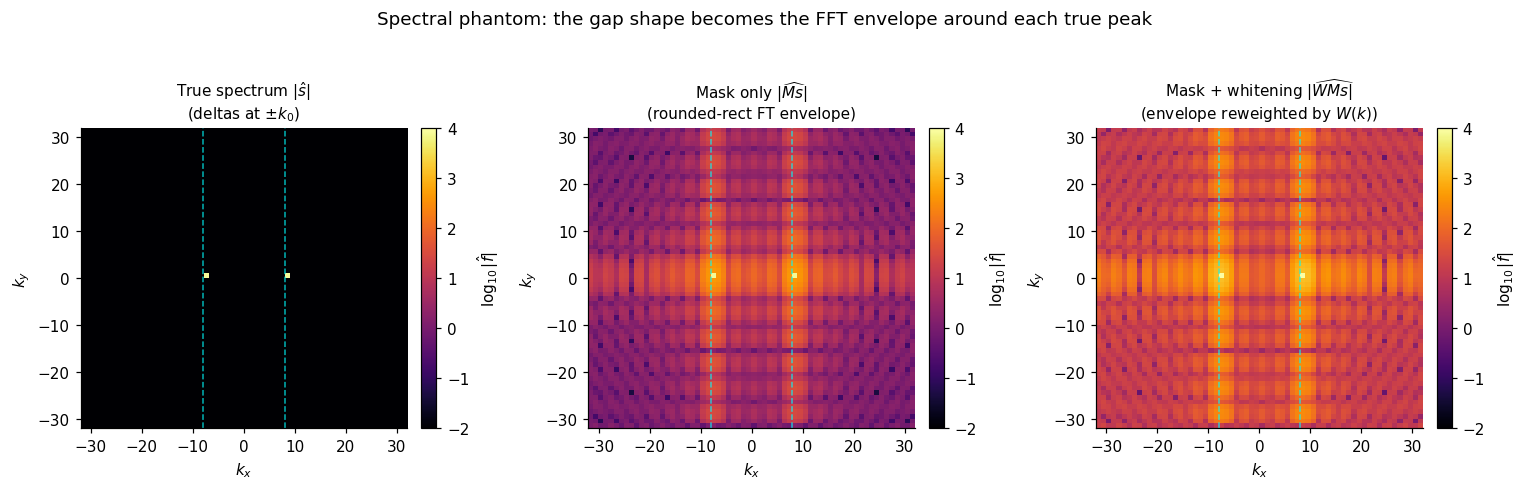

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

zoom_pix = N // 4
center_idx = N // 2
zoom_slice = slice(center_idx - zoom_pix, center_idx + zoom_pix)
k_zoom_max = (kx_arr[1] - kx_arr[0]) * zoom_pix
k_zoom_extent = [-k_zoom_max, k_zoom_max, -k_zoom_max, k_zoom_max]


def plot_spec(ax, S, title, vmin=-2, vmax=4):
    Ss = np.fft.fftshift(S)
    im = ax.imshow(np.log10(Ss[zoom_slice, zoom_slice] + 1e-3).T,
                   cmap='inferno', origin='lower', extent=k_zoom_extent,
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.axvline(k_0, color='cyan', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(-k_0, color='cyan', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10}|\hat{f}|$')


plot_spec(axes[0], spec_clean,
          r'True spectrum $|\hat{s}|$' + '\n(deltas at $\\pm k_0$)')
plot_spec(axes[1], spec_masked,
          r'Mask only $|\widehat{Ms}|$' + '\n(rounded-rect FT envelope)')
plot_spec(axes[2], spec_whitened_masked,
          r'Mask + whitening $|\widehat{WMs}|$' + '\n(envelope reweighted by $W(k)$)')

plt.suptitle('Spectral phantom: the gap shape becomes the FFT envelope around each true peak',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## §3. Cross-correlation (two streams, common mask)

### What we're computing

We have two independent measurement streams — think two detectors, two telescope visits, two seismic stations. Each observes a field through the same mask, with independent noise: $y^{(i)}(x) = M(x)\cdot(s(x) + n^{(i)}(x))$ for $i = 1, 2$. We then whiten each: $\tilde y^{(i)} = W y^{(i)}$, and form the *cross-correlation*
$$\hat C(\Delta) \;=\; \int \tilde y^{(1)}(x)\,\tilde y^{(2)}(x+\Delta)\,d^2x.$$
This is a function of the 2D spatial lag $\Delta = (\Delta_x, \Delta_y)$. It measures coherence between the two streams as a function of relative shift. If both streams contain a common coherent signal $s$ — say, a shared GW signal seen by both detectors — then $\hat C$ has a characteristic structure peaked near $\Delta = 0$ with a shape determined by the signal's autocorrelation. If the streams contain only independent noise, $\hat C$ is "small" — but the meaning of "small" turns out to depend on $\Delta$.

### Why the phantom appears under the null

Under the null hypothesis (no signal, just two independent noise streams), $\mathbb{E}[\hat C(\Delta)] = 0$ exactly. There is no first-moment phantom — on average, the cross-correlation is zero everywhere. But the *variance* of $\hat C(\Delta)$ across realizations of the noise is *not* uniform across $\Delta$. It has a 2D structure inherited from the geometry of the mask.

Here's the mechanism. At lag $\Delta$, the integrand $M(x)\,n_1(x)\,M(x+\Delta)\,n_2(x+\Delta)$ is non-zero only at points $x$ where *both* $x$ and $x+\Delta$ are in the unmasked region. Geometrically, this is the set $\{x : M(x) = 1\text{ and }M(x+\Delta) = 1\}$ — the intersection of the unmasked region with its translate by $-\Delta$. The 2D area of this intersection is exactly the mask autocorrelation
$$A_M(\Delta) \;=\; \int M(x)\,M(x+\Delta)\,d^2x.$$
For Gaussian white noise (we'll show shortly that whitening reduces to this case in spirit), the variance of the cross-correlation at lag $\Delta$ scales linearly with the area of overlap: $\mathrm{Var}[\hat C(\Delta)] \propto A_M(\Delta)$.

For our rounded-rectangle gap, $A_M(\Delta)$ is largest at $\Delta = 0$, where the mask completely overlaps with itself (intersection area = unmasked area). As $|\Delta|$ grows, the gap and its translate pull apart; once they're fully disjoint (which happens at $|\Delta_x| > 2W$ and $|\Delta_y| > 2H$ simultaneously), the intersection drops to a *plateau* equal to the unmasked area minus *twice* the gap area (you've removed two non-overlapping copies of the gap). So $A_M(\Delta)$ has a broad bump centered at $\Delta = 0$, with footprint approximately $2W \times 2H$ in the long and short directions, and the corner rounding from the gap inherits into the bump shape.

### Translation invariance

Even though we placed the gap *off-center* at $(1.5, 1.3)$, the variance bump in $\Delta$-space is centered at $\Delta = 0$. This is because $A_M$ is exactly translation-invariant: $\int M(x)\,M(x+\Delta)\,d^2x = \int M(x-\delta)\,M(x-\delta+\Delta)\,d^2x$ by change of variables, for any shift $\delta$. So *only the shape of the gap*, not its position, sets the cross-correlation phantom. This is the framework's claim made geometric: the two-point statistics of the gap (the autocorrelation) determine the phantom; the gap's location does not.

### Reading the figure

- **Left panel:** the empirical variance map $\mathrm{Var}[\hat C(\Delta)]$ from 1500 null Monte Carlo realizations. There's a clearly visible bright bump at the center of $\Delta$-space, with a rounded-rectangle footprint. The white dotted outline is the predicted footprint at $2W \times 2H$ with rounded corners — i.e., the place where $A_M$ should drop to its plateau. The structure inside the outline matches the mask geometry (you can see the rectangular shape with smoothed corners). Outside the outline, the variance is roughly uniform (the plateau).
- **Middle and right panels:** 1D slices through the bump along the long axis ($\Delta_y = 0$) and short axis ($\Delta_x = 0$), respectively. The vertical blue dotted lines mark $|\Delta_x| = 2W$ and $|\Delta_y| = 2H$, where $A_M$ transitions from the bump to the plateau. The variance does indeed transition there — peaked at zero lag, sloping down approximately linearly (the autocorrelation of a rectangle in 1D is a triangle), and leveling off at the predicted boundaries.

The numerical summary printed by the cell shows the peak/plateau ratio: about 1.04 — modest but nonzero. The bump excess above the plateau is $\sim 4\%$ here, set by the gap area as a fraction of the domain. Larger gaps would make this ratio larger; ours is small because the gap is small.

### Practical implication

Under the null, an analyst applying a uniform threshold $|\hat C(\Delta)| > k\sigma$ across all lags will get a non-uniform false-alarm rate: higher near $\Delta = 0$ where the variance is larger, lower at large $|\Delta|$. The expected number of "detections" clusters preferentially at small lags — exactly where a real coherent signal would cluster. To get a uniform false-alarm rate, you must threshold against the per-lag standard deviation $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]}$, computable in advance from the mask. We use this in §4.

In [6]:
def generate_colored_noise():
    # Generate one realization of 2D field with PSD S_n
    n_white = np.random.standard_normal((N, N))
    Z = np.fft.fft2(n_white)
    return np.real(np.fft.ifft2(Z * np.sqrt(S_n)))


def whiten(field):
    # Apply whitening filter W = 1/sqrt(S_n) in Fourier domain
    F = np.fft.fft2(field)
    return np.real(np.fft.ifft2(F * W_kernel))


# Monte Carlo: null distribution of Chat
n_real = 1500
sum_C = np.zeros((N, N))
sum_C_sq = np.zeros((N, N))

print(f'Running {n_real} null realizations through the full pipeline...')
for i in range(n_real):
    n1 = generate_colored_noise()
    n2 = generate_colored_noise()
    y1_w = whiten(M * n1)
    y2_w = whiten(M * n2)
    Y1 = np.fft.fft2(y1_w)
    Y2 = np.fft.fft2(y2_w)
    C = np.real(np.fft.ifft2(np.conj(Y1) * Y2)) * dx**2
    sum_C += C
    sum_C_sq += C**2
    if (i + 1) % 500 == 0:
        print(f'  realization {i+1}/{n_real}')

mean_C = sum_C / n_real
var_C = sum_C_sq / n_real - mean_C**2

print()
print(f'Variance map:')
print(f'  peak    = {var_C.max():.4f}  (at Delta near 0, where mask overlaps itself)')
print(f'  plateau = {var_C[N//2, N//2]:.4f}  (at large |Delta|, no overlap)')
print(f'  ratio   = {var_C.max() / var_C[N//2, N//2]:.3f}  (peak/plateau)')
print(f'  excess  = {var_C.max() - var_C[N//2, N//2]:.4f}  (the phantom amplitude)')

Running 1500 null realizations through the full pipeline...


  realization 500/1500


  realization 1000/1500


  realization 1500/1500

Variance map:
  peak    = 0.1000  (at Delta near 0, where mask overlaps itself)
  plateau = 0.0824  (at large |Delta|, no overlap)
  ratio   = 1.213  (peak/plateau)
  excess  = 0.0176  (the phantom amplitude)


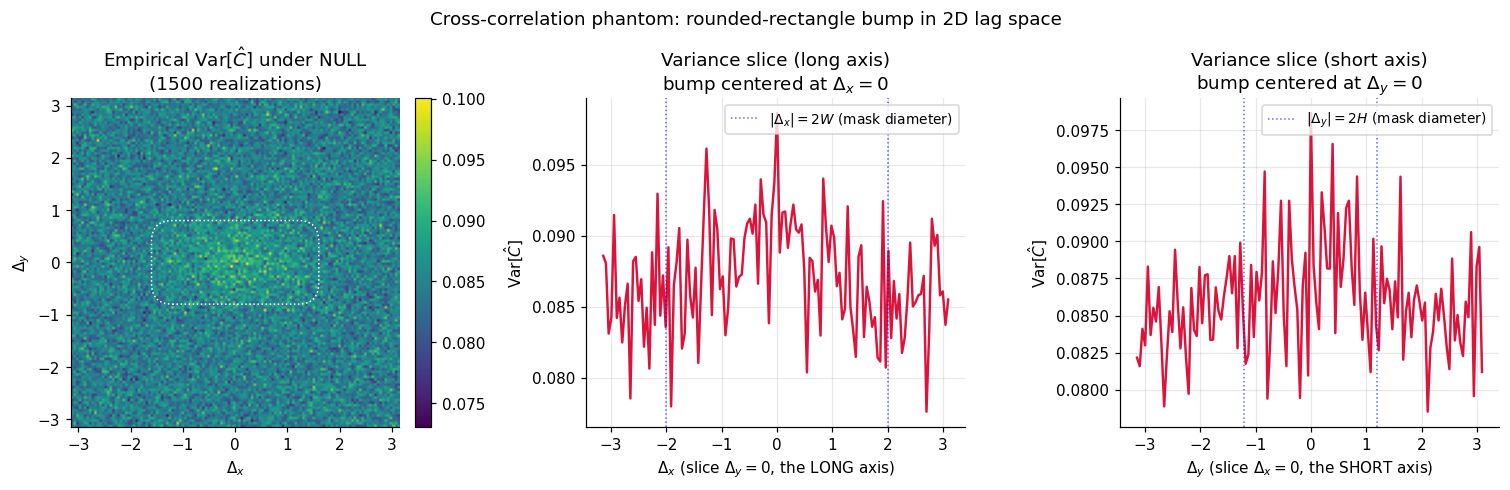

In [7]:
var_C_c = np.fft.fftshift(var_C)
lag_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
im = ax.imshow(var_C_c.T, cmap='viridis', origin='lower',
               extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, 2 * W_rect, 2 * H_rect, 2 * r_corner, 0, 0,
                     color='white', ls=':', lw=1.0)
ax.set_title(r'Empirical Var[$\hat{C}$] under NULL' + f'\n({n_real} realizations)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
center = N // 2
ax.plot(lag_axis, var_C_c[:, center], color='crimson', linewidth=1.6)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_x|=2W$ (mask diameter)')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$, the LONG axis)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (long axis)\nbump centered at $\\Delta_x=0$')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(lag_axis, var_C_c[center, :], color='crimson', linewidth=1.6)
ax.axvline(2 * H_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_y|=2H$ (mask diameter)')
ax.axvline(-2 * H_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_y$ (slice $\Delta_x=0$, the SHORT axis)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (short axis)\nbump centered at $\\Delta_y=0$')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Cross-correlation phantom: rounded-rectangle bump in 2D lag space',
             fontsize=12)
plt.tight_layout()
plt.show()

## §4. Real-signal detection through the full pipeline

### What we're computing

A coherent plane-wave signal $s(x,y) = \cos(k_0 x)$ with $k_0 = 8$ is added to *both* streams (same signal in both). We then run the full pipeline — observe through the gap, whiten, cross-correlate — and look at $\hat C(\Delta)$ for two cases:
- **Signal-only:** no noise added, just $y^{(i)} = WM s$ in both streams. The cross-correlation is $\hat C(\Delta) = (WMs) \star (WMs)$, the autocorrelation of the masked-and-whitened signal.
- **Signal + noise:** one realization with noise: $y^{(i)} = WM(s + n^{(i)})$ with independent $n^{(i)}$.

We then compare the realized $\hat C$ against the null phantom band — the $\pm 3\sigma$ envelope where $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]\,|\,\text{null}}$ from §3. A detection above the band is one that rules out the null at >$3\sigma$ at that lag.

### What "phantom band" means precisely

The phantom band is the gray region in the rightmost panel below: a *non-uniform* envelope, $\pm 3\sigma(\Delta_x)$ along the slice $\Delta_y = 0$. The width of the band varies with lag — wider near $\Delta = 0$ where the variance bump from §3 is highest, narrower at large $|\Delta|$ where the variance is at its plateau. It tells you the *typical magnitude of $\hat C$ at each lag under the null*: where you'd need to exceed to claim detection at >$3\sigma$.

The first-moment phantom would be a non-zero *mean* in the cross-correlation under the null — like the twin peaks in the §2 spectrum, where mask leakage shifts the *expected* value of the matched-filter output. There is no first-moment phantom in the cross-correlation case: $\mathbb{E}[\hat C(\Delta)] = 0$ exactly under the null, regardless of the mask. The phantom band is a *second-moment* phantom: the structured null variance, a function of $\Delta$ rather than a constant.

### What the signal cross-correlation looks like

The signal $s(x,y) = \cos(k_0 x)$ is a coherent plane wave along the $x$-direction, constant along $y$. Its cross-correlation with itself, computed through the masked-and-whitened pipeline, has two key features:
1. *Vertical stripes in $\Delta$-space.* The autocorrelation of a 1D cosine at $k_0$ is itself a cosine at $k_0$: $(s \star s)(\Delta_x) \propto \cos(k_0 \Delta_x)$. So $\hat C(\Delta)$ shows oscillations along $\Delta_x$ at the source frequency.
2. *Constant along $\Delta_y$.* Since $s$ doesn't depend on $y$, the cross-correlation has no structure in $\Delta_y$.
The masked-and-whitened version of this is the same cosine pattern, slightly attenuated by the mask and reweighted by $W$. The signal punches through the phantom band by orders of magnitude in our setup.

### Shape discrimination — beyond magnitude

In the figure below, signal-to-band ratio is $\sim 100$+ at peak — the signal is overwhelming. But what if the SNR were lower, say signal amplitude comparable to $3\sigma$? Could you still discriminate signal from phantom?

Yes — by *shape* in lag space. The signal has Fourier content in $\hat C$ at lag-frequency $\pm(k_0, 0) = \pm(8, 0)$ — sharp peaks. The phantom variance bump from §3 is a smooth blob of width $\sim 1/W \sim 1$ in lag-frequency, concentrated at low $|k|$. So the signal and the phantom live in *different frequency bands of the cross-correlation* — the signal is high-frequency oscillation in $\Delta_x$; the phantom is low-frequency variation. A bandpass filter on $\hat C(\Delta)$ — keep only modes with $|k_x| \approx k_0$, $|k_y|$ small — extracts the signal cleanly even when the signal amplitude is well below $3\sigma$ in raw terms.

This is the practical content of "shape, not just magnitude" as a detection principle: the framework predicts both *the magnitude scale* (the band) and *the spectral location* (the phantom is at low frequencies in lag-space, the signal is at $k_0$). Pipelines that exploit both are robust at lower SNR than ones that only threshold magnitude.

### Reading the figure

- **Left:** signal-only cross-correlation through the pipeline. Pure cosine stripes in $\Delta_x$, constant in $\Delta_y$. Amplitude $\sim 150$.
- **Middle:** signal + noise (one realization). Same stripes are visible — noise is small relative to signal.
- **Right:** 1D slice through $\Delta_y = 0$. The gray band is the $\pm 3\sigma$ phantom envelope from §3. The red curve is signal + noise; the dashed black is signal-only. The signal's cosine oscillation has amplitude $\sim 150$, the band has half-width $\sim 0.85$ at its widest. Punches through trivially. The blue dotted lines mark $|\Delta_x| = 2W$, where the band transitions from the bump region to the plateau.

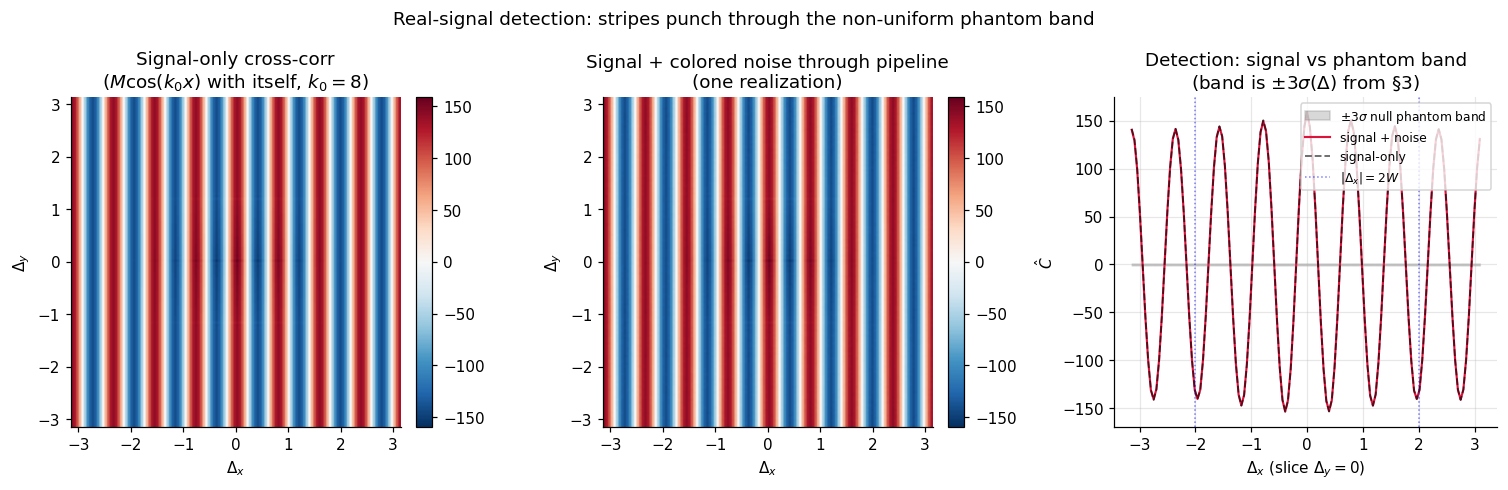

In [8]:
# Signal-only through pipeline (no noise)
y1_so = whiten(M * signal)
y2_so = whiten(M * signal)
C_signal_only = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_so)) * np.fft.fft2(y2_so))) * dx**2

# Signal + colored noise (one realization)
n1_sig = generate_colored_noise()
n2_sig = generate_colored_noise()
y1_sig = whiten(M * (signal + n1_sig))
y2_sig = whiten(M * (signal + n2_sig))
C_with_signal = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_sig)) * np.fft.fft2(y2_sig))) * dx**2

C_signal_only_c = np.fft.fftshift(C_signal_only)
C_with_signal_c = np.fft.fftshift(C_with_signal)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
vmax = np.abs(C_signal_only_c).max()
im = ax.imshow(C_signal_only_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(f'Signal-only cross-corr\n($M\\cos(k_0 x)$ with itself, $k_0={int(k_0)}$)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
vmax2 = np.abs(C_with_signal_c).max()
im = ax.imshow(C_with_signal_c.T, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title('Signal + colored noise through pipeline\n(one realization)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[2]
sigma_band = np.sqrt(var_C_c[:, center])
ax.fill_between(lag_axis, -3 * sigma_band, 3 * sigma_band, color='gray',
                alpha=0.30, label=r'$\pm 3\sigma$ null phantom band')
ax.plot(lag_axis, C_with_signal_c[:, center], color='crimson', linewidth=1.4,
        label='signal + noise')
ax.plot(lag_axis, C_signal_only_c[:, center], color='black', linewidth=1.2,
        linestyle='--', alpha=0.6, label='signal-only')
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
           label=r'$|\Delta_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$)')
ax.set_ylabel(r'$\hat{C}$')
ax.set_title('Detection: signal vs phantom band\n(band is $\\pm 3\\sigma(\\Delta)$ from §3)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Real-signal detection: stripes punch through the non-uniform phantom band',
             fontsize=12)
plt.tight_layout()
plt.show()

## §5. Power spectrum (PSD) estimation

### What we're computing

The power spectral density of a stationary noise field $n$ is
$$S_n(k) \;=\; \mathbb{E}\bigl[|\hat n(k)|^2\bigr]\,\Big/\,N^2$$
in our discrete-FFT normalization. The standard estimator is the *periodogram*: take one realization, compute $|\hat n(k)|^2/N^2$, and average across many realizations to reduce variance. This is the bread-and-butter of PSD estimation in spectral analysis, signal processing, time-series analysis, and observational cosmology (where it's called the "pseudo-$C_\ell$" estimator on a cut sky).

In this section we examine how the periodogram behaves when the field is observed only through the mask $M$. The estimator becomes $|\widehat{Mn}(k)|^2/N^2$. The question: what does this estimate, in expectation?

### Why the phantom appears

The masked field's FFT is the convolution of the FFT of the mask with the FFT of the noise:
$$\widehat{Mn}(k) \;=\; \frac{1}{N^d}(\hat M * \hat n)(k) \;=\; \frac{1}{N^d}\sum_q \hat M(k - q)\,\hat n(q)$$
where $d = 2$ here is the spatial dimension. For Gaussian noise, the squared magnitude has expectation
$$\mathbb{E}\bigl[|\widehat{Mn}(k)|^2\bigr] \;=\; \frac{1}{N^d}\bigl(|\hat M|^2 * S_n\bigr)(k)$$
— the true PSD $S_n$ *convolved with the magnitude-squared FFT of the mask*. Each frequency in the masked periodogram averages over a neighborhood of the true PSD, weighted by the kernel $|\hat M|^2$. This is the **mask-induced spectral leakage**: power at one frequency $k$ leaks into nearby frequencies $k'$ in proportion to $|\hat M(k - k')|^2$.

The kernel $|\hat M|^2$ is concentrated near $k = 0$ (since $\hat M(0) = \int M\,d^2x = $ unmasked area, which is large), with width $\sim 1/W$ along $k_x$ and $\sim 1/H$ along $k_y$ (set by the gap dimensions). A small gap → narrow kernel → mild smearing. A large gap → broad kernel → severe smearing. Our gap is small relative to the domain ($\sim 4\%$ of area), so the smearing is *mild* — the masked PSD is barely distinguishable from the true PSD by eye.

The phenomenon is more dramatic for sharper PSDs. If the true $S_n$ has a narrow peak (a monochromatic line, a glitch frequency, etc.), the convolution with $|\hat M|^2$ broadens that peak by the kernel width. Sharp features in the spectrum are "smeared out" by the gap; the masked periodogram cannot resolve features narrower than $\sim 1/W$ along $k_x$ or $\sim 1/H$ along $k_y$.

### The connection to pseudo-$C_\ell$

This is exactly the *mode-mixing matrix* used in CMB and large-scale structure analysis on a cut sky:
$$M_{\ell\ell'} \;=\; \frac{2\ell+1}{4\pi}\sum_m \bigl|W_{\ell\ell'm}\bigr|^2$$
where $W$ is the spherical-harmonic transform of the mask. The pseudo-$C_\ell$ estimator gives $\mathbb{E}[\hat C_\ell^{\rm masked}] = M_{\ell\ell'}\,C_{\ell'}$ — true $C_{\ell}$ convolved with a known coupling matrix that depends only on the mask. *Inverting* this convolution to recover the true $C_\ell$ from the masked estimator is exactly the *pseudo-$C_\ell$ deconvolution*. The framework's perspective: this is the same operator phantom that shows up in 2D PSD estimation, just on a different domain (sphere vs torus) and basis (spherical harmonics vs Fourier).

### Reading the figure

- **Top row, three panels:** 2D log-magnitude spectra. (Left) the true PSD $S_n$, scaled to match periodogram units. (Middle) the framework prediction $(|\hat M|^2 * S_n)/N^2$ — a known quantity, computed from $M$ and $S_n$ alone, no realizations needed. (Right) the empirical mean of $|\widehat{Mn}|^2$ over 300 realizations. Middle and right should match to Monte Carlo error; for 300 realizations, that's about $1/\sqrt{300} \approx 5.8\%$ per pixel.
- **Bottom panel:** 1D slice through $k_y = 0$, log-vertical. The black curve is the true PSD. The blue is the predicted masked PSD — visibly *attenuated at the peak* (the gap removed some unmasked area, lowering the average power) and *contaminated in the wings* (spectral leakage spreads peak power outward). The red dots are empirical points; they sit on the blue prediction within scatter.

### Practical implication

Two takeaways. First: the masked PSD is biased. In our case the bias is mild (small gap → narrow kernel), but for masks comparable in size to the spectral features of interest, the bias can be qualitatively significant — sharp features become broad, line widths inflate, peak heights drop. Second: the bias has a known shape, set by $|\hat M|^2$. The standard remedy is *deconvolution* — invert the mode-mixing operator to recover an unbiased estimate. This works for a known mask but introduces noise amplification in the reverse direction (the inverse of a smearing kernel is a sharpening kernel, which is unstable). Multitaper methods (Thomson, Slepian sequences) are an alternative that pre-engineers a family of masks whose collective bias is benign across many tapers.

In [9]:
# Predicted bias: <|hat(Mn)|^2>(k) = (|hat M|^2 conv S_n)(k) / N^2
M_fft_sq = np.abs(np.fft.fft2(M))**2

# Cyclic 2D convolution of |hat M|^2 with S_n in k-space
# (a conv b)[k] = ifft2( fft2(a) * fft2(b) )
psd_predicted = np.real(np.fft.ifft2(
    np.fft.fft2(M_fft_sq) * np.fft.fft2(S_n))) / N**2

# Empirical: average periodogram of masked field
n_real_psd = 300
sum_psd_masked = np.zeros((N, N))
for i in range(n_real_psd):
    n_real_sample = generate_colored_noise()
    sum_psd_masked += np.abs(np.fft.fft2(M * n_real_sample))**2
psd_empirical = sum_psd_masked / n_real_psd

# Verification: how close is empirical to predicted?
significant_psd = S_n > S_n.max() * 0.05
mean_rel_err_psd = np.mean(np.abs(psd_empirical[significant_psd] -
                                     psd_predicted[significant_psd]) /
                              psd_predicted[significant_psd])
print(f'Empirical / predicted comparison (significant region):')
print(f'  Mean relative error: {mean_rel_err_psd:.3e}')
print(f'  (Should be ~ 1/sqrt({n_real_psd}) ~ {1/np.sqrt(n_real_psd):.3f} for MC noise)')

Empirical / predicted comparison (significant region):
  Mean relative error: 4.345e-02
  (Should be ~ 1/sqrt(300) ~ 0.058 for MC noise)


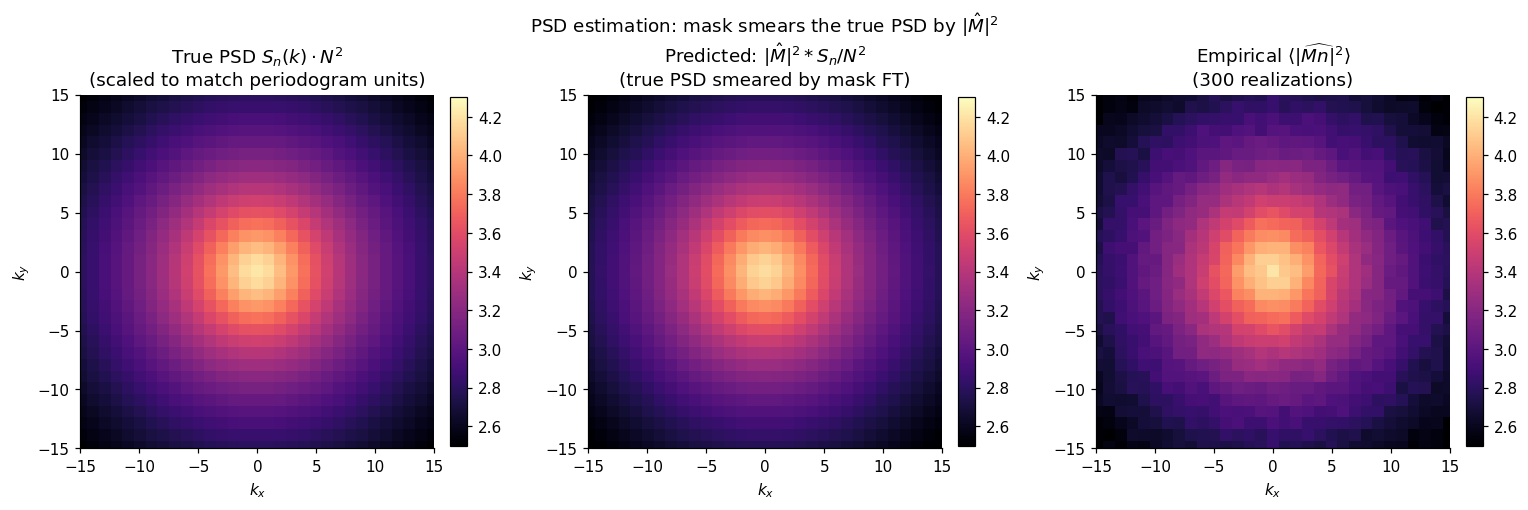

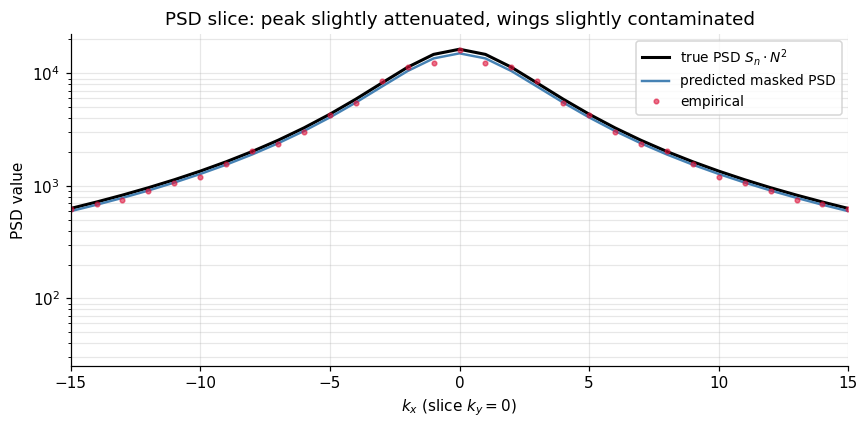

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

S_n_c = np.fft.fftshift(S_n)
psd_pred_c = np.fft.fftshift(psd_predicted)
psd_emp_c = np.fft.fftshift(psd_empirical)

# Use a color scale that matches the actual data range
vmin_psd, vmax_psd = 2.5, 4.3

# True PSD
ax = axes[0]
im = ax.imshow(np.log10(S_n_c.T * N**2), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(r'True PSD $S_n(k)\cdot N^2$' + '\n(scaled to match periodogram units)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Predicted masked PSD
ax = axes[1]
im = ax.imshow(np.log10(psd_pred_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title('Predicted: $|\\hat M|^2 * S_n / N^2$\n(true PSD smeared by mask FT)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Empirical masked periodogram
ax = axes[2]
im = ax.imshow(np.log10(psd_emp_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(f'Empirical $\\langle|\\widehat{{Mn}}|^2\\rangle$\n'
             f'({n_real_psd} realizations)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

plt.suptitle('PSD estimation: mask smears the true PSD by $|\\hat M|^2$',
             fontsize=12)
plt.tight_layout()
plt.show()

# 1D radial profile comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ky_zero_idx = N // 2
kx_centered = np.fft.fftshift(kx_arr)
ax.semilogy(kx_centered, S_n_c[:, ky_zero_idx] * N**2,
            color='black', linewidth=2, label=r'true PSD $S_n \cdot N^2$')
ax.semilogy(kx_centered, psd_pred_c[:, ky_zero_idx],
            color='steelblue', linewidth=1.6, label='predicted masked PSD')
ax.semilogy(kx_centered, psd_emp_c[:, ky_zero_idx],
            'o', color='crimson', markersize=3, alpha=0.6, label='empirical')
ax.set_xlim(-15, 15)
ax.set_xlabel('$k_x$ (slice $k_y = 0$)')
ax.set_ylabel('PSD value')
ax.set_title('PSD slice: peak slightly attenuated, wings slightly contaminated')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## §6. Two-point correlation function (autocorrelation)

### What we're computing

The two-point correlation function of a stationary field $f$ is
$$\xi(r) \;=\; \mathbb{E}\bigl[f(x)\,f(x+r)\bigr]$$
— a function of the spatial lag $r$ only (not of the absolute position $x$, by stationarity). It is the inverse Fourier transform of the PSD: $\xi(r) = \mathcal{F}^{-1}[S_n](r)$, the real-space twin of the spectral analysis from §5. In cosmology it's used as the headline statistic for galaxy clustering (the galaxy two-point function $\xi_{gg}(r)$); in time-series analysis it shows up as the autocovariance function.

The standard *raw* estimator from masked data is
$$\hat\xi_{\rm raw}(r) \;=\; \frac{1}{V}\int M(x)\,f(x)\,M(x+r)\,f(x+r)\,d^2x$$
— exactly the masked autocorrelation. Computed via FFT, this is $\mathcal{F}^{-1}[|\widehat{Mf}|^2]/V$, the inverse Fourier transform of the masked field's periodogram.

### Why the phantom appears

Take the expectation:
$$\mathbb{E}\bigl[\hat\xi_{\rm raw}(r)\bigr] \;=\; \frac{1}{V}\int M(x)\,M(x+r)\,\mathbb{E}\bigl[f(x)f(x+r)\bigr]\,d^2x \;=\; \frac{A_M(r)}{V}\,\xi(r),$$
where $A_M(r) = \int M(x)\,M(x+r)\,d^2x$ is the same mask autocorrelation that controls the cross-correlation phantom in §3. The raw estimator is *multiplicatively biased* by the geometric factor $A_M(r)/V$ — the fraction of pairs at separation $r$ that are *both* unmasked.

This factor has a clean physical interpretation. To estimate $\xi(r)$, you average products $f(x)f(x+r)$ over all spatial points $x$. With a mask, only those $x$ where both $x$ *and* $x+r$ are unmasked contribute. The *number* of such valid pairs (per unit $x$-volume) is $A_M(r)/V$. The raw estimator divides the sum of valid pairs by the *total* domain volume $V$ instead of by the number of valid pairs — so it underestimates by exactly $A_M(r)/V$.

### The Landy-Szalay correction

The fix is to divide by the actual number of valid pairs:
$$\hat\xi_{\rm corr}(r) \;=\; \frac{\hat\xi_{\rm raw}(r)}{A_M(r)/V}$$
This is a *known geometric correction* — $A_M(r)$ depends only on the mask, computable in advance via FFT. After dividing, $\mathbb{E}[\hat\xi_{\rm corr}] = \xi$ — the bias is removed.

In galaxy survey analysis, this is exactly the **Landy-Szalay estimator**:
$$\hat\xi_{LS}(r) \;=\; \frac{DD(r) - 2\,DR(r) + RR(r)}{RR(r)}$$
where $DD$ is the count of data-data pairs at separation $r$, $DR$ is data-random pairs, $RR$ is random-random pairs (using a "random catalog" with the same survey footprint but no clustering). The denominator $RR$ is *exactly $A_M(r)$* in the limit of an infinitely-dense random catalog. The Landy-Szalay form is asymptotically equivalent to our $\hat\xi_{\rm raw}/(A_M/V)$, with extra terms that reduce edge-effect bias at finite $r$. The correction is the same geometric quantity in both cases.

### Bias correction does not eliminate the variance phantom

It's important to note that dividing by $A_M(r)/V$ corrects the *mean* of the estimator, but does not eliminate the *variance* phantom. Under the null, $\mathrm{Var}[\hat\xi_{\rm corr}(r)]$ still has structure inherited from the mask. To get fully calibrated detection, you need both the bias correction (here, in the mean) and the variance map (analogous to §3's variance bump for the cross-correlation case). Both are computable in advance from the mask; both must be used together.

### Reading the figure

**Top row** — 2D maps:
- Left: true $\xi(r)$. Sharp peak at $r = 0$ (the field variance), decaying with correlation length $\sim 1/k_c \approx 0.33$.
- Middle: raw biased $\hat\xi_{\rm raw}$. Same shape but lower amplitude — the multiplicative bias.
- Right: corrected $\hat\xi_{\rm corr} = \hat\xi_{\rm raw}/(A_M(r)/V)$. Back to the true amplitude.

**Bottom row** — 1D radial profiles and verification:
- Left: 1D slice through $r_y = 0$. The black curve (true $\xi$) and red dots (corrected) overlay; blue (raw) sits below them by the predicted bias factor $A_M(0)/V \sim 0.94$ at $r=0$.
- Middle: the geometric correction factor $A_M(r)/V$ itself, plotted vs $r$. Peaks at $A_M(0)/V = 1 - $ (gap area)/V $\approx 0.94$ at zero lag, decreases to $\sim 0.88 = 1 - 2\,$(gap area)/V at large $|r|$ (where the mask and its translate are fully disjoint). Note the y-axis is zoomed: the bias is small (~10%), reflecting that our gap is small.
- Right: empirical bias ratio $\hat\xi_{\rm raw}/\xi_{\rm true}$ overlaid on the predicted $A_M/V$. The empirical ratio (red dots) follows the predicted curve (green) closely — the bias-correction formula is verified.

### Practical implication

The Landy-Szalay correction is *the* standard tool for survey-footprint-aware clustering analysis in cosmology. It works because the geometric correction factor is computable in advance from the mask — the survey doesn't introduce new free parameters. In other domains (time-series autocovariance, geomagnetic field analysis, cardiac signal analysis) the same correction applies whenever you have a known data-quality mask. The framework's perspective: this is a first-moment phantom (the bias) being corrected by a known geometric factor; the second-moment phantom (the variance) still requires per-lag threshold calibration, just like §3.

In [11]:
# Mask autocorrelation (the geometric factor)
A_M = np.real(np.fft.ifft2(np.abs(np.fft.fft2(M))**2)) * dx**2
A_M_normalized = A_M / V  # dimensionless geometric factor in (0, 1]

# True xi from PSD: xi(r) = ifft(S_n)  (with proper normalization)
# Our generate_colored_noise gives <|hat n|^2> = N^2 * S_n
# Spatial autocorrelation: <n(x) n(x+r)> = ifft(<|hat n|^2>) / V_grid
# = ifft(N^2 S_n) / N^2 = ifft(S_n)
xi_true = np.real(np.fft.ifft2(S_n))

# Empirical raw and corrected estimators
n_real_xi = 200
sum_xi_raw = np.zeros((N, N))

print(f'Running {n_real_xi} realizations for xi estimation...')
for i in range(n_real_xi):
    n_sample = generate_colored_noise()
    Mn = M * n_sample
    # Raw estimator: ifft(|fft(Mn)|^2) gives sum_x M(x)n(x) M(x+r)n(x+r)
    # Divide by V_grid = N^2 to get average
    xi_raw = np.real(np.fft.ifft2(np.abs(np.fft.fft2(Mn))**2)) / N**2
    sum_xi_raw += xi_raw

mean_xi_raw = sum_xi_raw / n_real_xi

# Apply Landy-Szalay-style correction
mask_safe = A_M_normalized > 0.01
mean_xi_corrected = np.where(mask_safe,
                                 mean_xi_raw / A_M_normalized,
                                 0)

# Check at zero lag (= field variance)
print(f'\nAt r=0 (field variance):')
print(f'  True xi(0) = {xi_true[0,0]:.4f}')
print(f'  Raw estimator:        {mean_xi_raw[0,0]:.4f} '
      f'(biased by A_M(0)/V = {A_M_normalized[0,0]:.3f})')
print(f'  Corrected estimator:  {mean_xi_corrected[0,0]:.4f}')
print(f'  -> Landy-Szalay-style correction recovers truth.')

Running 200 realizations for xi estimation...



At r=0 (field variance):
  True xi(0) = 0.0109
  Raw estimator:        0.0103 (biased by A_M(0)/V = 0.942)
  Corrected estimator:  0.0109
  -> Landy-Szalay-style correction recovers truth.


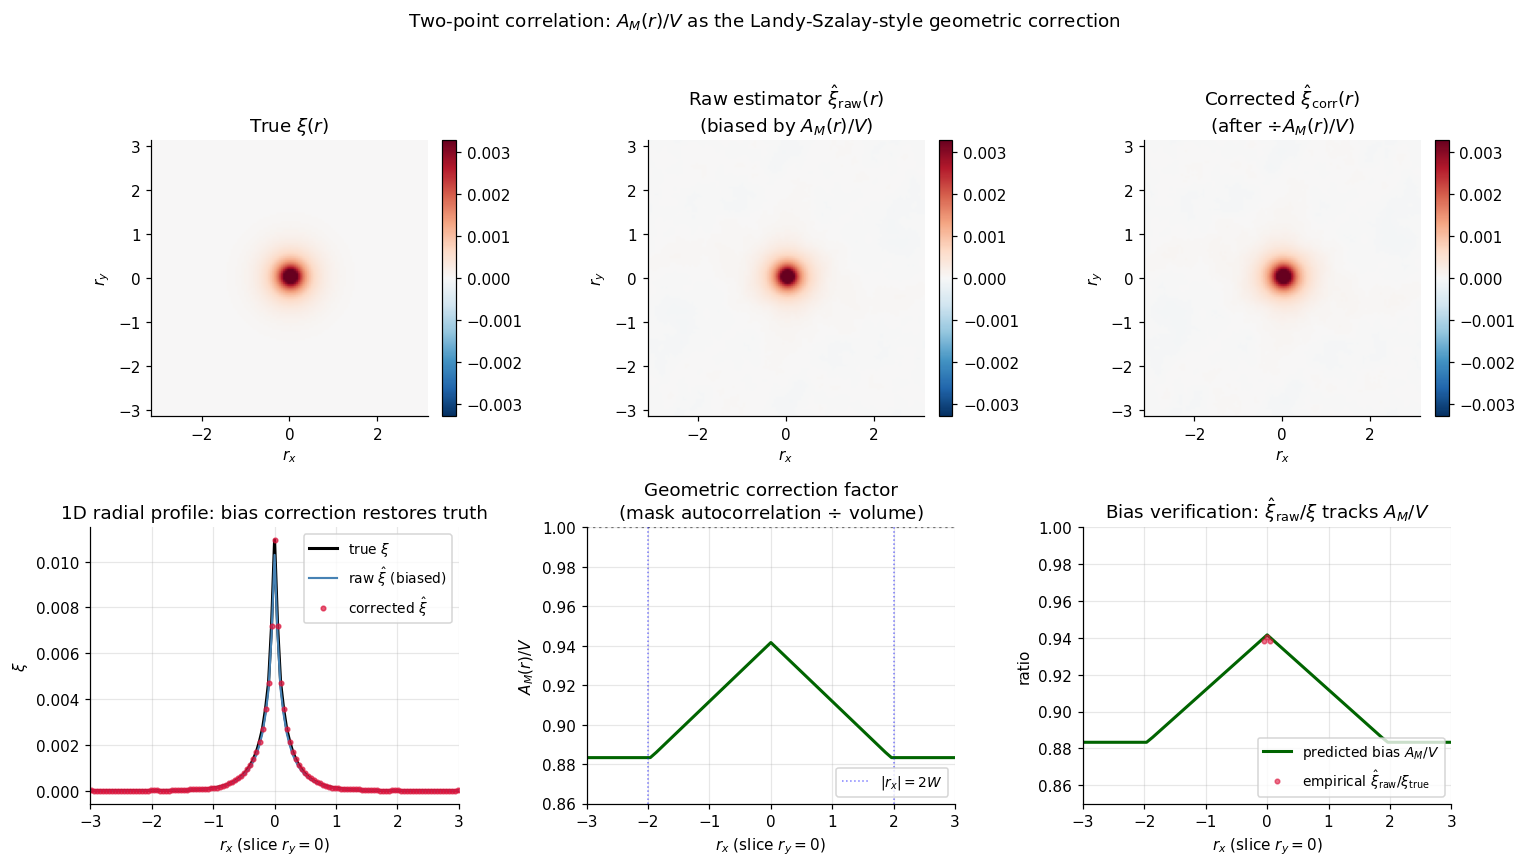

In [12]:
xi_true_c = np.fft.fftshift(xi_true)
mean_xi_raw_c = np.fft.fftshift(mean_xi_raw)
mean_xi_corrected_c = np.fft.fftshift(mean_xi_corrected)
A_M_normalized_c = np.fft.fftshift(A_M_normalized)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Top row: 2D xi maps
vmax = xi_true_c.max() * 0.3

ax = axes[0, 0]
im = ax.imshow(xi_true_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'True $\xi(r)$')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
im = ax.imshow(mean_xi_raw_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Raw estimator $\hat\xi_{\rm raw}(r)$' + '\n(biased by $A_M(r)/V$)')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(mean_xi_corrected_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Corrected $\hat\xi_{\rm corr}(r)$' +
             '\n(after $\\div A_M(r)/V$)')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Bottom row: 1D radial profiles + geometric factor
r_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)
center_idx = N // 2

ax = axes[1, 0]
ax.plot(r_axis, xi_true_c[:, center_idx], color='black', linewidth=2,
        label=r'true $\xi$')
ax.plot(r_axis, mean_xi_raw_c[:, center_idx], color='steelblue', linewidth=1.4,
        label=r'raw $\hat\xi$ (biased)')
ax.plot(r_axis, mean_xi_corrected_c[:, center_idx], 'o', color='crimson',
        markersize=3, alpha=0.7, label=r'corrected $\hat\xi$')
ax.set_xlim(-3, 3)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$\xi$')
ax.set_title('1D radial profile: bias correction restores truth')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2)
ax.axhline(1.0, color='black', linestyle=':', alpha=0.5)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
            label=r'$|r_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlim(-3, 3); ax.set_ylim(0.86, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$A_M(r)/V$')
ax.set_title('Geometric correction factor\n(mask autocorrelation $\\div$ volume)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 2]
# Ratio of raw to true: should equal A_M/V
ratio_emp = np.where(np.abs(xi_true_c[:, center_idx]) > 0.005,
                       mean_xi_raw_c[:, center_idx] / xi_true_c[:, center_idx],
                       np.nan)
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2,
        label=r'predicted bias $A_M/V$')
ax.plot(r_axis, ratio_emp, 'o', color='crimson', markersize=3, alpha=0.6,
        label=r'empirical $\hat\xi_{\rm raw}/\xi_{\rm true}$')
ax.set_xlim(-3, 3); ax.set_ylim(0.85, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel('ratio')
ax.set_title('Bias verification: $\\hat\\xi_{\\rm raw}/\\xi$ tracks $A_M/V$')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Two-point correlation: $A_M(r)/V$ as the Landy-Szalay-style geometric correction',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §7. Wiener inpainting — and the framework's lower bound

### What we're computing

In contrast to the previous sections (which estimate aggregate statistics), Wiener inpainting estimates the *field itself* in the masked region. Given observations $y(x) = M(x)\cdot(s(x) + n(x))$ (the field + noise, masked), produce an estimate $\hat s(x)$ of the underlying field across the *entire* domain — including the masked region. This is the spatial analog of "filling in missing data."

The optimal Bayesian estimator (assuming Gaussian priors on the field and noise) is the *Wiener filter*. For a stationary field with PSD $S_f$ and noise with PSD $S_n$, the closed-form solution on *unmasked* data is just a Fourier-domain multiplication:
$$\hat s(k) \;=\; \frac{S_f(k)}{S_f(k) + S_n(k)}\,\hat y(k)$$
This is the optimal linear filter that minimizes mean squared reconstruction error. With masking, the closed form requires inverting a non-stationary operator $(M\Sigma_f M^T + \Sigma_n)$ on the order of (number of unmasked pixels) — typically infeasible at our 128×128 scale. Instead we use the *POCS* (Projection Onto Convex Sets) iterative algorithm, which converges to the same answer.

### How the POCS iteration works

Start with $\hat s^{(0)} = y$ (the observation, with masked pixels at zero). At each iteration:
1. **Prior step:** Apply the unmasked Wiener filter, $\hat s^{(k+1/2)} = \mathcal{F}^{-1}[(S_f/(S_f+S_n))\,\mathcal{F}[\hat s^{(k)}]]$. This *enforces the field's spectral prior* — pulls the current estimate toward field PSD $S_f$.
2. **Data fidelity step:** Replace observed pixels with the actual observations: $\hat s^{(k+1)}(x) = M(x)\cdot y(x) + (1 - M(x))\cdot \hat s^{(k+1/2)}(x)$. This *enforces consistency with the data* — re-pins the estimate to known values outside the gap.

Iterating alternately enforces both constraints. The fixed point is the optimal Wiener estimate of $s$ given the masked observations. Convergence is fast: ~10-30 iterations suffice for typical setups. We use 40 iterations here to be safe.

### What the framework predicts

The principal-angle decomposition tells you, *before any reconstruction*, the limit of what's recoverable. At any point $x_0$ inside the gap, define
$$\beta(x_0) \;=\; \text{(fraction of a localized signal at $x_0$ that lives in the unmasked region)}.$$
$\beta(x_0)$ ranges from 0 (signal at $x_0$ is fully invisible to the unmasked region) to 1 (signal at $x_0$ is fully observable from the unmasked region). For a stationary field with correlation length $\ell$:
- Near the mask boundary ($x_0$ within $\ell$ of $\partial\text{mask}$): $\beta(x_0)$ is close to 1 — the field at $x_0$ correlates with nearby observations.
- Deep in the mask interior ($x_0$ farther than $\ell$ from the boundary): $\beta(x_0) \to 0$ — the field at $x_0$ is decorrelated from any observation.

The reconstruction error variance has a lower bound: $\mathrm{Var}[s(x_0) - \hat s_{\rm Wiener}(x_0)] \geq (1 - \beta(x_0))\cdot\mathrm{Var}[s(x_0)]$. The factor $(1 - \beta)$ is the framework's **suppression** scalar: the irreducible fraction of variance you cannot recover, because that variance lives in modes the mask cannot "see."

For our setup: noise correlation length $\ell = 1/k_c \approx 0.33$. Gap interior depth: max $\sim 0.5$. So the deepest interior points are about $1.5\,\ell$ from the boundary — borderline recoverable. The error map below confirms: error grows from boundary to interior, plateauing around the noise correlation length scale.

### Wiener inpainting vs the framework

Wiener inpainting *achieves* the framework's lower bound — for Gaussian fields with known PSDs, the Wiener estimator is the Bayes-optimal linear estimator. Non-Wiener inpainting methods (sparsity-based, dictionary-learning, deep CNN inpainters, score-based diffusion models) can sometimes do better than Wiener *for non-Gaussian fields with structured priors* (natural images, sparse representations) — by exploiting structure beyond the second-order statistics. But for fully Gaussian fields, Wiener is the floor — no linear method does better, and the framework's $\beta$ tells you how much error remains.

### Reading the figure

**Top row, three panels:**
- Left: the *truth* — one realization of the colored random field with PSD $S_n$. Speckle pattern with ~$0.33$ correlation length.
- Middle: the *observation* $M\cdot(\text{truth} + \text{measurement noise})$ — same field but with the off-center gap masked out (white region). A small additional measurement noise was added (std $0.05$) to regularize the inversion.
- Right: the *Wiener-inpainted reconstruction* — gap region filled in by the iterative algorithm. Visually similar to truth in the unmasked region (re-pinned to data) and a smoother estimate inside the gap (the Wiener filter favors low-frequency completion).

**Bottom row:**
- Left: the *reconstruction error* (truth minus inpainted), shown only inside the gap. Non-zero, with structure related to where information was lost.
- Middle: the *distance into the gap from the boundary* — a geometric map. The deepest point is at the mask center ($\sim 0.5$ from any boundary).
- Right: *error magnitude vs distance into the gap*. Each red dot is a single pixel inside the gap; the black line is the binned mean. Error increases with distance from the boundary, leveling off around $1/k_c$ — the noise correlation length. Beyond that scale, the field is essentially decorrelated from the boundary observations; further depth doesn't make it harder to reconstruct because the answer is already "we don't know."

### Practical implication

For *small* gaps (gap diameter $\lesssim$ correlation length), Wiener inpainting recovers the missing field well — the error is mostly noise from measurement uncertainty, not from missing information. Our setup is borderline: gap size $\sim 1$, correlation length $\sim 0.33$, so the deepest interior is $\sim 1.5\,\ell$ from the boundary. Recovery there is partial.

For *large* gaps (gap diameter $\gg$ correlation length), the deep interior is essentially unrecoverable from boundary information alone. The framework gives the precise lower bound: $\beta(x_0)$ tells you exactly how much variance remains. No amount of clever inpainting can overcome this — additional information (priors, side data, multiple wavelengths, etc.) is required.

In [13]:
# Iterative Wiener inpainting (POCS-like)
def wiener_inpaint(y_observed, M_mask, S_signal_psd, S_noise_psd, n_iter=30):
    # y_observed: M * (s + noise), with masked pixels = 0
    # M_mask: indicator of unmasked region
    # S_signal_psd: prior PSD for signal
    # S_noise_psd: noise PSD on observation
    f = y_observed.copy()
    W_filter = S_signal_psd / (S_signal_psd + S_noise_psd)
    for k in range(n_iter):
        # Wiener filter step (enforces spectral prior)
        F = np.fft.fft2(f)
        f_filtered = np.real(np.fft.ifft2(F * W_filter))
        # Re-impose observed pixels (enforces data fidelity)
        f = M_mask * y_observed + (1 - M_mask) * f_filtered
    return f


# Generate one realization of the colored field as the "truth"
np.random.seed(0)
truth_field = generate_colored_noise()

# Add a small amount of measurement noise (regularizes the inversion)
sigma_meas = 0.05
S_meas_const = sigma_meas**2 * np.ones_like(S_n)
noise_meas = sigma_meas * np.random.standard_normal((N, N))
y_observed = M * (truth_field + noise_meas)

# Run iterative Wiener
inpainted = wiener_inpaint(y_observed, M, S_signal_psd=S_n,
                            S_noise_psd=S_meas_const, n_iter=40)

# Reconstruction error inside the mask
error_field = truth_field - inpainted
err_rms_per_pixel = np.abs(error_field)
truth_rms = np.sqrt(np.mean(truth_field**2))
in_gap_mask = (1 - M).astype(bool)
print(f'Truth field RMS: {truth_rms:.4f}')
print(f'Mean abs error in gap: {err_rms_per_pixel[in_gap_mask].mean():.4f}')
print(f'Max abs error in gap: {err_rms_per_pixel[in_gap_mask].max():.4f}')
print(f'  (Error is largest in deep interior, smallest near boundary)')

Truth field RMS: 0.1037
Mean abs error in gap: 0.0807
Max abs error in gap: 0.3219
  (Error is largest in deep interior, smallest near boundary)


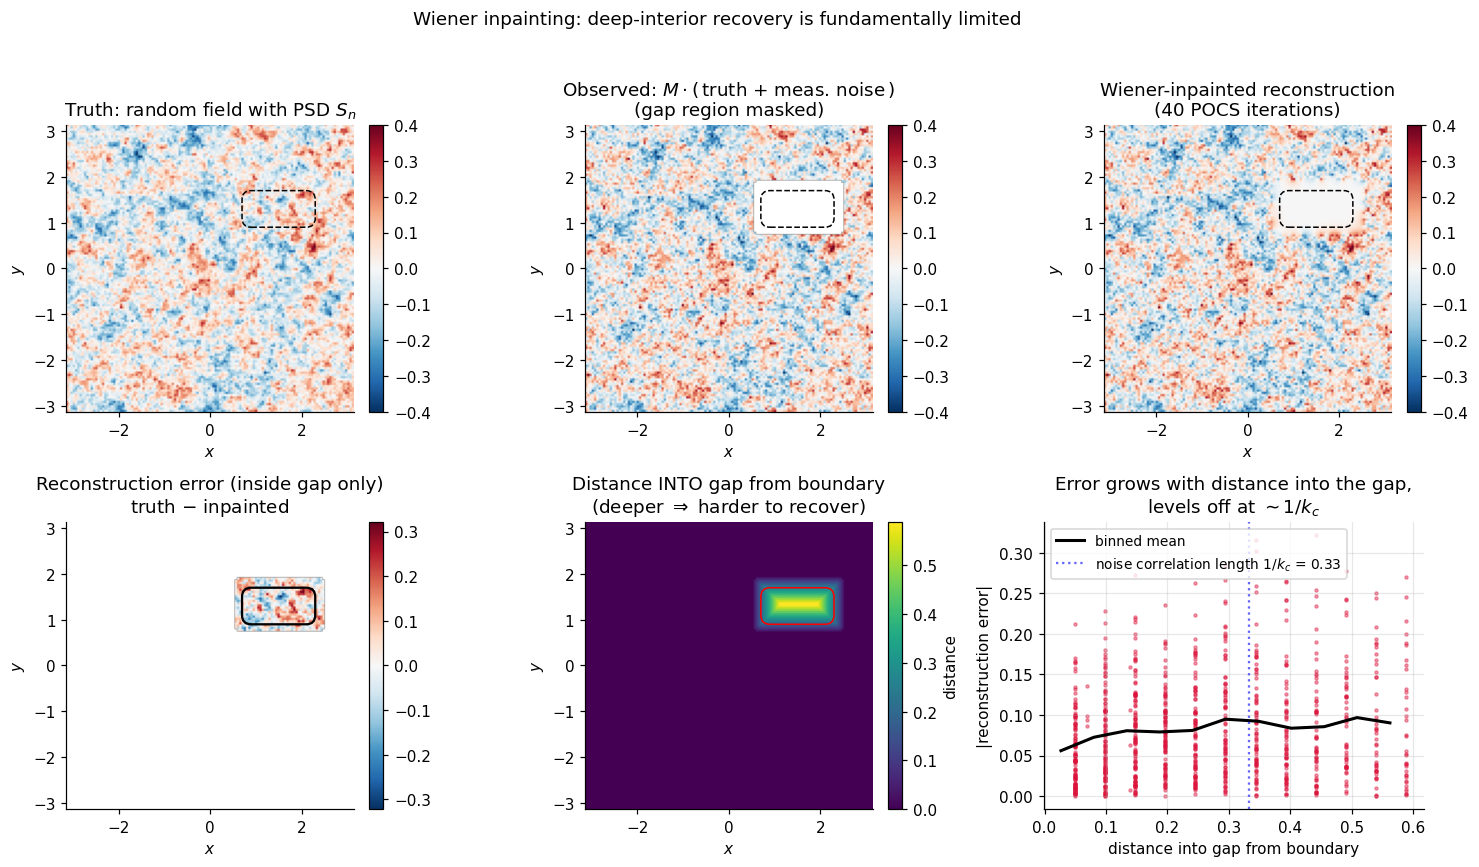

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Common color scale for the truth/observed/reconstruction triplet
vmax = np.abs(truth_field).max() * 0.9

ax = axes[0, 0]
im = ax.imshow(truth_field.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Truth: random field with PSD $S_n$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
y_observed_display = y_observed.copy()
y_observed_display[in_gap] = np.nan
im = ax.imshow(y_observed_display.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Observed: $M\\cdot(\\,$truth + meas. noise$\\,)$\n(gap region masked)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(inpainted.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Wiener-inpainted reconstruction\n(40 POCS iterations)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Bottom row: error analysis
ax = axes[1, 0]
err_display = error_field.copy()
err_display[M.astype(bool)] = np.nan  # show only inside the gap
err_vmax = np.nanmax(np.abs(err_display))
im = ax.imshow(err_display.T, cmap='RdBu_r', vmin=-err_vmax, vmax=err_vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='-', lw=1.5)
ax.set_title('Reconstruction error (inside gap only)\ntruth $-$ inpainted')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Distance from gap boundary inside the gap
from scipy import ndimage
dist_from_edge = ndimage.distance_transform_edt(in_gap_mask) * dx

ax = axes[1, 1]
im = ax.imshow(dist_from_edge.T, cmap='viridis', origin='lower',
                extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='red', ls='-', lw=1.0)
ax.set_title('Distance INTO gap from boundary\n'
             '(deeper $\\Rightarrow$ harder to recover)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label='distance')

# Error vs distance inside gap
ax = axes[1, 2]
in_gap_pix = in_gap_mask
ax.scatter(dist_from_edge[in_gap_pix], np.abs(error_field[in_gap_pix]),
            s=4, alpha=0.4, color='crimson')
# Add binned average
bins = np.linspace(0, dist_from_edge[in_gap_pix].max(), 12)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_means = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    sel = (dist_from_edge[in_gap_pix] >= bins[i]) & \
          (dist_from_edge[in_gap_pix] < bins[i+1])
    if sel.any():
        bin_means[i] = np.abs(error_field[in_gap_pix][sel]).mean()
    else:
        bin_means[i] = np.nan
ax.plot(bin_centers, bin_means, color='black', linewidth=2,
        label='binned mean')
ax.axvline(1/k_c, color='blue', linestyle=':', alpha=0.6,
            label=f'noise correlation length $1/k_c$ = {1/k_c:.2f}')
ax.set_xlabel('distance into gap from boundary')
ax.set_ylabel('|reconstruction error|')
ax.set_title('Error grows with distance into the gap,\nlevels off at $\\sim 1/k_c$')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Wiener inpainting: deep-interior recovery is fundamentally limited',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §8. Synthesis

One mask geometry — a small, off-center, rounded rectangle — produces a distinct phantom signature in every downstream computation. All six are predictable in advance from the same gap shape:

| Computation | Phantom signature | Mask object that controls it |
|---|---|---|
| Spectral matched filter (§2) | Rounded-rect FT envelope around each delta in spectrum | $\lvert\hat M(k)\rvert$ |
| Cross-correlation (§3) | Rounded-rect bump in 2D lag space, sized $2W\times 2H$ | $A_M(\Delta) = \int M(x)M(x{+}\Delta)\,d^2x$ |
| Detection (§4) | Phantom $\pm 3\sigma(\Delta)$ band in lag space | $\sqrt{A_M(\Delta)}$ (variance bump from §3) |
| PSD estimation (§5) | True PSD smeared by $\lvert\hat M\rvert^2$ — the mode-mixing/pseudo-$C_\ell$ kernel | $\lvert\hat M(k)\rvert^2$ as smearing kernel |
| Two-point function (§6) | Multiplicative bias by $A_M(r)/V$ — exactly the Landy-Szalay correction | $A_M(r)/V$ |
| Wiener inpainting (§7) | Reconstruction error grows with distance into gap; lower bound by suppression | Principal-angle parameter $\beta(x_0)$ |

### Why position vs shape matter differently

Translating the mask in space changes only the *phase* of $\hat M$, not its magnitude. So all the spectral-domain phantoms (§2, §5) and lag-space phantoms based on autocorrelation (§3, §6) are exactly invariant under translation: their shape and amplitude depend only on the *gap shape*, not its location. Wiener inpainting (§7) is the exception — it cares about gap *position* because the *interior* of the gap (a position-dependent set) is geometrically where information is fundamentally lost. So:
- For aggregate statistics (PSD, $\xi$, cross-correlation): only gap *shape* matters.
- For spatial recovery (inpainting): both shape *and* position matter, in the form of distance-to-boundary maps.

### Why whitening doesn't fix any of this

Whitening is a *frequency-dependent rescaling* in Fourier space; it commutes with anything in Fourier space (multiplications) but not with anything in real space (multiplications by $M$). So:
- §2 spectral phantom: just gets pointwise reweighted by $W(k)$ — the rounded-rectangle envelope is preserved, only the amplitudes change. The phantom is *reshaped* but not removed.
- §3-§6: the mask shape still controls the geometry of every phantom; whitening rescales overall amplitudes but doesn't change shapes.
- §7: whitening doesn't affect the principal-angle structure of which signal modes the mask can see. The information loss is structural, not amplitude-dependent.

The point is general: there's no "preprocessing trick" that eliminates the mask-induced structure. The mask is a physical fact about the data; the framework's claim is that you can predict its consequences exactly, and you should — calibration based on $|\hat M|$, $A_M$, and $\beta(x_0)$ is the only way to get unbiased downstream conclusions.

### What the framework gives you

For each of these six computations, the framework provides:
1. **A predicted shape** for the phantom in the appropriate domain (spectrum, lag space, real space).
2. **A predicted amplitude** as a function of the mask geometry.
3. **A discrimination strategy**: real signals have shapes that differ from phantoms in a known way (e.g., signal lives at $k_0$ in the cross-correlation, phantom lives at low frequencies; signal in $\xi$ matches the underlying correlation, bias matches $A_M$).
4. **A threshold calibration** that's per-frequency or per-lag, computed from the mask before any data is collected.

All of this is precomputable from the mask alone (or mask + noise model, both knowable). The actionable content is: do this calibration; don't try to outsmart the geometry by post-processing alone.